# Data Exploration - REPSOL Classification Dataset

This notebook explores WAV recordings and spectrogram metadata for the REPSOL classification dataset.

- Notebook path: `C:\home\ben\REPSOL`
- Classification path: `D:\REPSOL_Classification`
- The classification dataset contains 8 category folders.
- Each category folder contains `.wav` files.
- Each category folder also contains one `Espectrograma` folder with spectrogram images.

Example naming convention:
- WAV: `SM301165__0__20161001_161201_1.wav`
- Spectrogram: `SM301165__0__20161001_161201_1_spectrogram_win16384.png`

## 1. Setup

In [1]:
# !pip install pandas numpy matplotlib soundfile seaborn

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import soundfile as sf
import seaborn as sns

Define absolute paths and output locations.

In [2]:
NOTEBOOK_DIR = Path(r"C:\home\ben\REPSOL")
CLASSIFICATION_DIR = Path(r"D:\REPSOL_Classification")
SPECTROGRAM_FOLDER_NAME = "Espectrograma"

ANNOT_DIR = NOTEBOOK_DIR / "outputs"
ANNOT_DIR.mkdir(parents=True, exist_ok=True)
ANNOT_FILE = ANNOT_DIR / "audio_annotations.csv"

if not CLASSIFICATION_DIR.exists():
    raise FileNotFoundError(f"Classification path not found: {CLASSIFICATION_DIR}")

category_dirs = [d for d in CLASSIFICATION_DIR.iterdir() if d.is_dir()]
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Classification directory: {CLASSIFICATION_DIR}")
print(f"Detected category folders: {len(category_dirs)}")
print("Categories:", [d.name for d in category_dirs])
print(f"Output CSV path: {ANNOT_FILE}")

Notebook directory: C:\home\ben\REPSOL
Classification directory: D:\REPSOL_Classification
Detected category folders: 8
Categories: ['0 ActividadBASE_NO pattern activity', '1 Pulses HAMMERING', '2 Marked cycles 3 segundos', '3 Continuous activity & tone 3.15kHz_SPL ALTO', '4 Continuous activity & tone 3.15kHz_ SPL BAJO', '5 Blasts', '6 Machinery continuous activity', '7 Works_ sirens and knocks en altas frecuencias RAFAGAS a 3.15']
Output CSV path: C:\home\ben\REPSOL\outputs\audio_annotations.csv


## 2. Build Metadata Table

In [3]:
records = []

for cat in category_dirs:
    wav_files = list(cat.rglob("*.wav"))
    espectrograma_dir = cat / SPECTROGRAM_FOLDER_NAME

    for audio_file in wav_files:
        try:
            info = sf.info(audio_file)
            duration = info.frames / info.samplerate if info.samplerate else 0.0
            expected_spectrogram = espectrograma_dir / f"{audio_file.stem}_spectrogram_win16384.png"

            records.append({
                "category": cat.name,
                "filename": audio_file.name,
                "duration_sec": duration,
                "sample_rate": info.samplerate,
                "spectrogram_exists": expected_spectrogram.exists()
            })
        except Exception as e:
            print(f"Error reading {audio_file}: {e}")

df_audio = pd.DataFrame(records)
df_audio.to_csv(ANNOT_FILE, index=False)

print("Total WAV files processed:", len(df_audio))
print("Metadata saved to:", ANNOT_FILE)
df_audio.head()

Total WAV files processed: 1976
Metadata saved to: C:\home\ben\REPSOL\outputs\audio_annotations.csv


,category,filename,duration_sec,sample_rate,spectrogram_exists
0,0 ActividadBASE_NO pattern activity,SM301165__0__20161001_013201_1.wav,60.0,96000,False
1,0 ActividadBASE_NO pattern activity,SM301165__0__20161001_013201_2.wav,60.0,96000,False
2,0 ActividadBASE_NO pattern activity,SM301165__0__20161001_013201_3.wav,60.0,96000,False
3,0 ActividadBASE_NO pattern activity,SM301165__0__20161001_051201_1.wav,60.0,96000,False
4,0 ActividadBASE_NO pattern activity,SM301165__0__20161001_051201_2.wav,60.0,96000,False


## 3. Number of Audio Files per Category

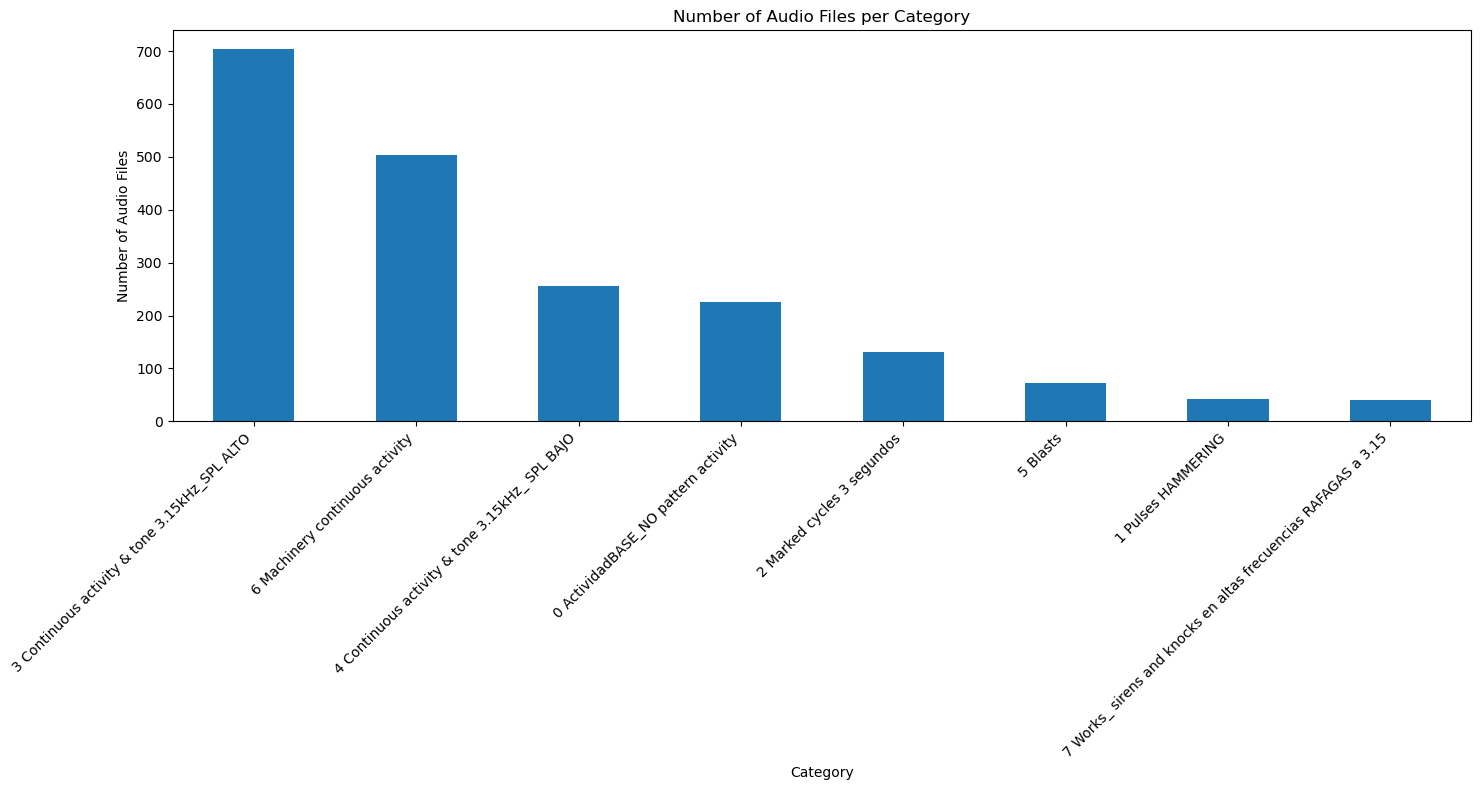

In [4]:
if df_audio.empty:
    print("No audio files found.")
else:
    category_counts = df_audio["category"].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(15, 8))
    category_counts.plot(kind="bar")
    plt.xlabel("Category")
    plt.ylabel("Number of Audio Files")
    plt.title("Number of Audio Files per Category")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Total Audio Duration per Category

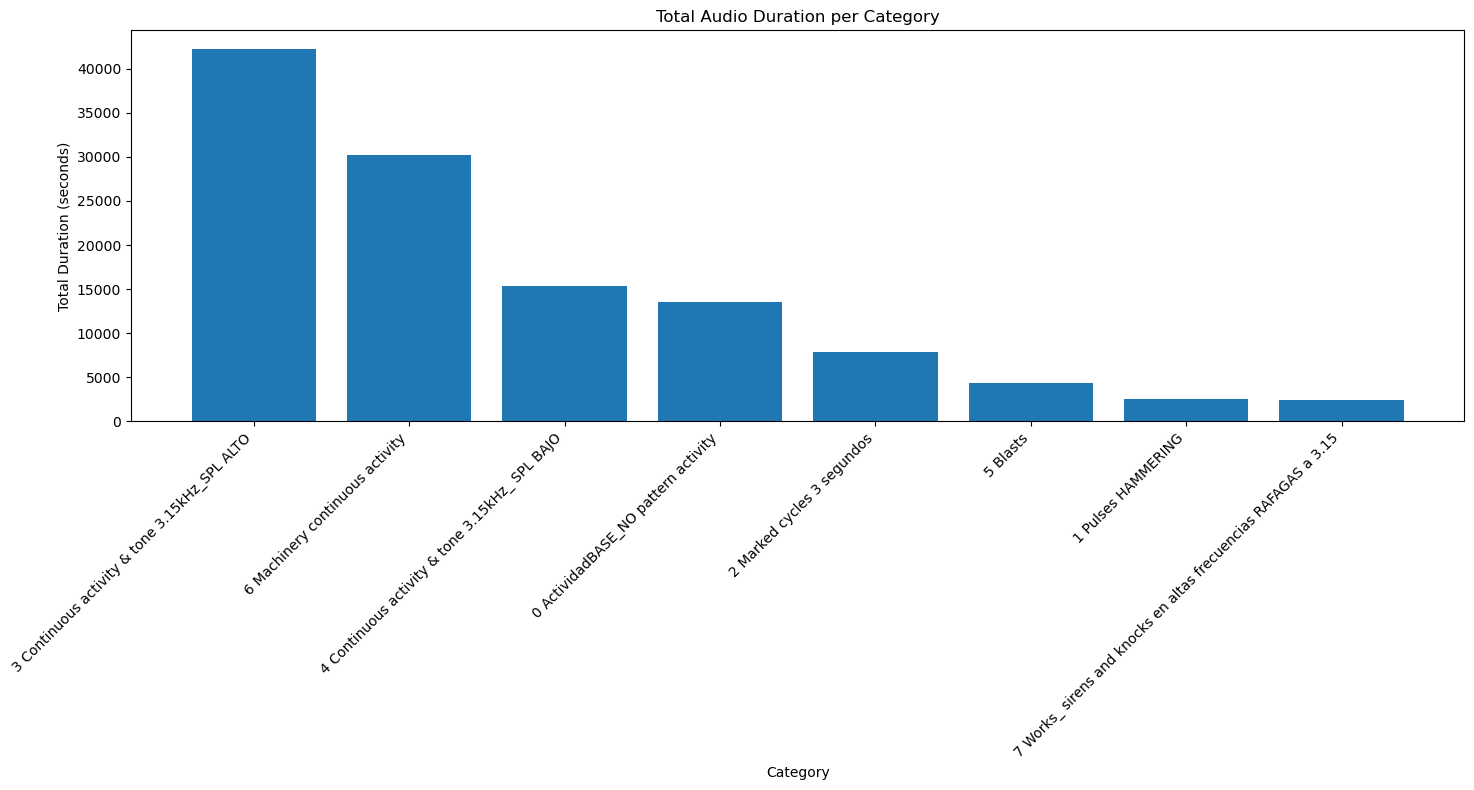

In [5]:
if df_audio.empty:
    print("No audio files found.")
else:
    category_durations = df_audio.groupby("category")["duration_sec"].sum().sort_values(ascending=False)

    plt.figure(figsize=(15, 8))
    plt.bar(category_durations.index, category_durations.values)
    plt.xlabel("Category")
    plt.ylabel("Total Duration (seconds)")
    plt.title("Total Audio Duration per Category")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Audio Files per Category and Sample Rate

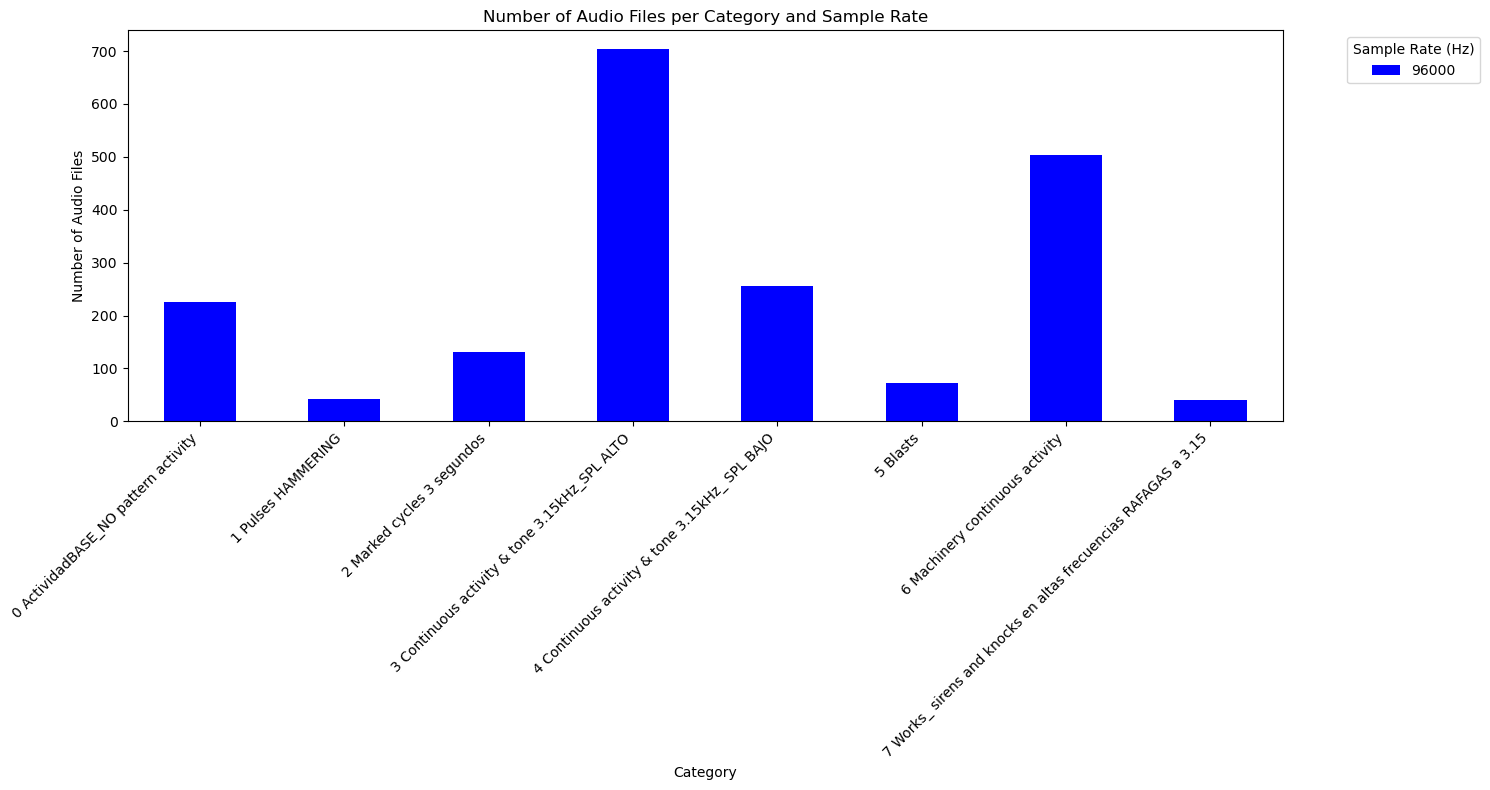

In [6]:
if df_audio.empty:
    print("No audio files found.")
else:
    pivot_df = (
        df_audio.groupby(["category", "sample_rate"]).size()
        .unstack(fill_value=0)
        .sort_index()
    )

    sample_rates = sorted(pivot_df.columns.tolist())
    n_colors = len(sample_rates)

    start_color = np.array(mcolors.to_rgb("blue"))
    end_color = np.array(mcolors.to_rgb("red"))

    if n_colors <= 1:
        colors = [tuple(start_color)]
    else:
        colors = [
            tuple(start_color + (end_color - start_color) * i / (n_colors - 1))
            for i in range(n_colors)
        ]

    ax = pivot_df.plot(kind="bar", stacked=True, figsize=(15, 8), color=colors)
    ax.set_xlabel("Category")
    ax.set_ylabel("Number of Audio Files")
    ax.set_title("Number of Audio Files per Category and Sample Rate")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Sample Rate (Hz)", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Color scale used in the stacked chart: blue indicates lower sample rates and red indicates higher sample rates.

## 6. Dataset Statistics

In [7]:
if df_audio.empty:
    print("No audio files found.")
else:
    total_files = len(df_audio)
    total_categories = df_audio["category"].nunique()
    avg_duration = df_audio["duration_sec"].mean()
    median_duration = df_audio["duration_sec"].median()
    min_duration = df_audio["duration_sec"].min()
    max_duration = df_audio["duration_sec"].max()
    spectrogram_coverage = df_audio["spectrogram_exists"].mean() * 100

    print(f"Total files: {total_files}")
    print(f"Total categories: {total_categories}")
    print(f"Average duration (s): {avg_duration:.2f}")
    print(f"Median duration (s): {median_duration:.2f}")
    print(f"Min duration (s): {min_duration:.2f}")
    print(f"Max duration (s): {max_duration:.2f}")
    print(f"Spectrogram coverage (%): {spectrogram_coverage:.2f}")

Total files: 1976
Total categories: 8
Average duration (s): 60.00
Median duration (s): 60.00
Min duration (s): 60.00
Max duration (s): 60.00
Spectrogram coverage (%): 79.71


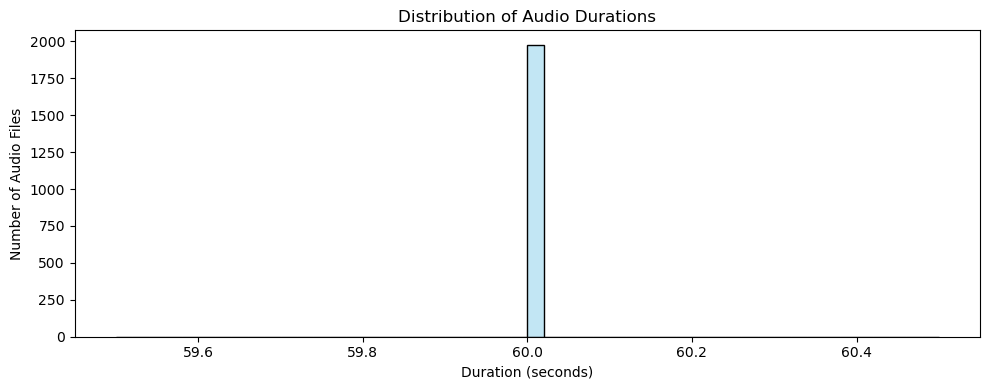

In [8]:
if df_audio.empty:
    print("No audio files found.")
else:
    plt.figure(figsize=(10, 4))
    sns.histplot(df_audio["duration_sec"], bins=50, kde=True, color="skyblue")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Number of Audio Files")
    plt.title("Distribution of Audio Durations")
    plt.tight_layout()
    plt.show()

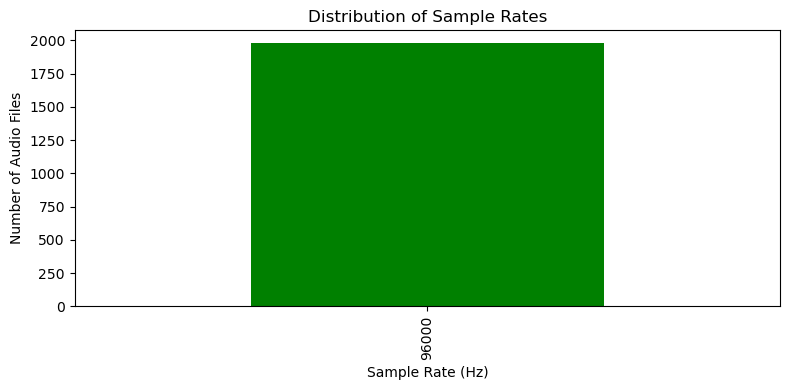

In [9]:
if df_audio.empty:
    print("No audio files found.")
else:
    sample_rate_counts = df_audio["sample_rate"].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    sample_rate_counts.plot(kind="bar", color="green")
    plt.xlabel("Sample Rate (Hz)")
    plt.ylabel("Number of Audio Files")
    plt.title("Distribution of Sample Rates")
    plt.tight_layout()
    plt.show()